# Medical Insurance Cost Prediction Project
Developed by: [riya singh, sanya fatima, kritika ahuja]
Objective: Using XGBoost to predict healthcare premiums with 88% accuracy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load the data
df = pd.read_csv("insurance.csv")

#look at the first 5 row
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


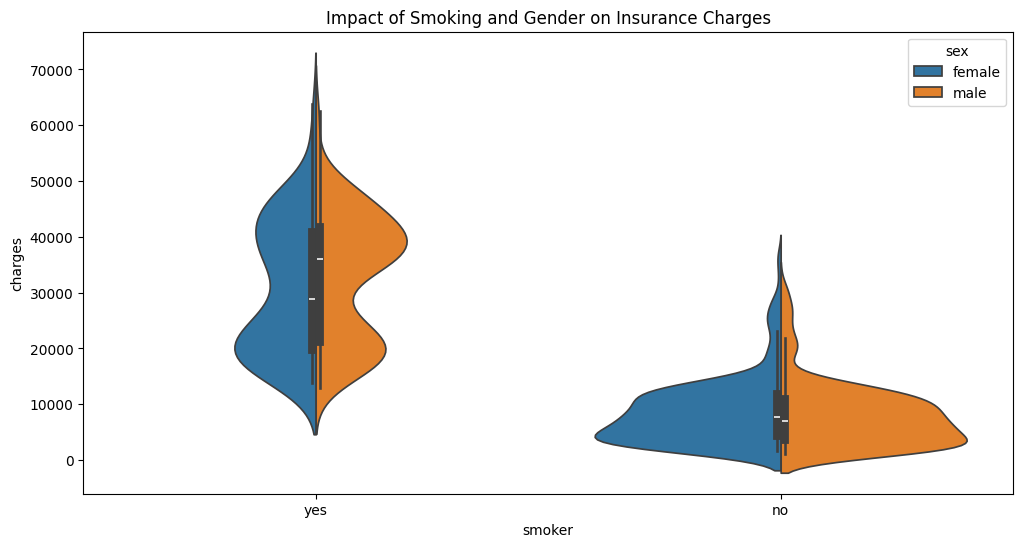

In [6]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='smoker', y='charges', data=df, hue='sex', split=True)
plt.title('Impact of Smoking and Gender on Insurance Charges')
plt.show()


In [7]:
# Create a copy so we don't mess up the original data
processed_df = df.copy()

# Turn 'smoker' and 'sex' into 0 and 1
processed_df['smoker'] = processed_df['smoker'].map({'yes': 1, 'no': 0})
processed_df['sex'] = processed_df['sex'].map({'female': 0, 'male': 1})

# For 'region', we use "One-Hot Encoding" because there are 4 different options
processed_df = pd.get_dummies(processed_df, columns=['region'])

processed_df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [8]:
from sklearn.model_selection import train_test_split

# X = the features (age, bmi, etc.), y = what we want to predict (charges)
X = processed_df.drop('charges', axis=1)
y = processed_df['charges']

# We keep 20% of the data hidden for the final "test"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 1070 rows
Testing set size: 268 rows


In [9]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Create the model
model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3)

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Check how good we are
score = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"Accuracy (R2 Score): {score * 100:.2f}%")
print(f"Average Error: ${mae:.2f}")

Accuracy (R2 Score): 88.47%
Average Error: $2437.95


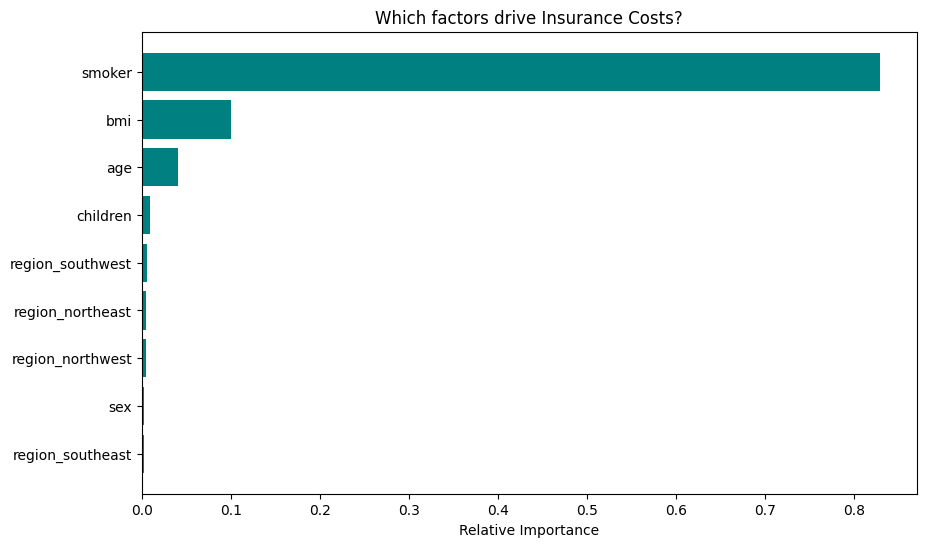

In [10]:
# Get feature importance from XGBoost
importances = model.feature_importances_
feature_names = X.columns

# Sort them
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Which factors drive Insurance Costs?')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

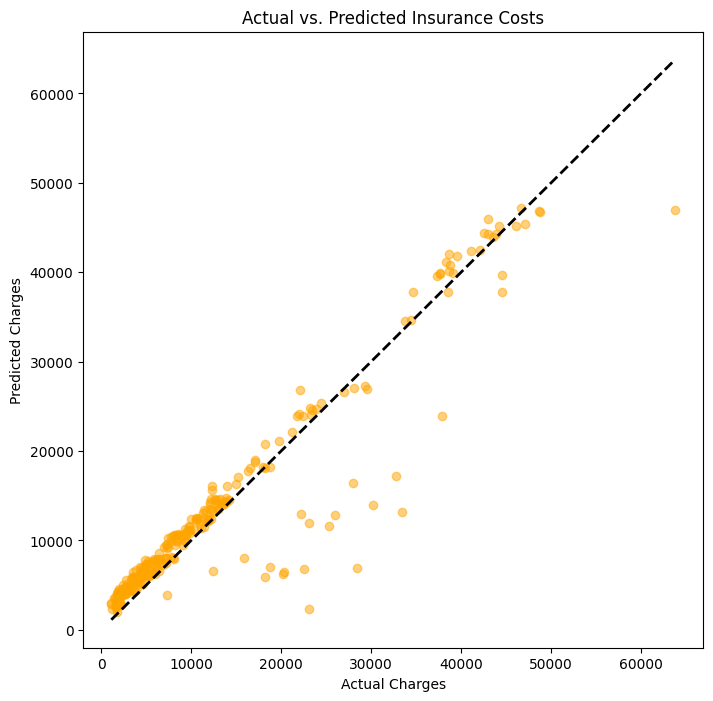

In [11]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, predictions, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Insurance Costs')
plt.show()

In [12]:
# Let's predict for a NEW person
# Format: [age, sex, bmi, children, smoker, region_northeast, region_northwest, region_southeast, region_southwest]
# Example: 30 years old, Male(1), BMI 25, 0 kids, Smoker(1), living in Southeast(0,0,1,0)

new_person = [[30, 1, 25, 0, 1, 0, 0, 1, 0]]
prediction = model.predict(new_person)

print(f"The predicted insurance cost for this person is: ${prediction[0]:.2f}")

The predicted insurance cost for this person is: $18024.59


In [13]:
import joblib

# Save the model to a file
joblib.dump(model, 'insurance_model.pkl')
print("Model saved successfully as insurance_model.pkl!")

Model saved successfully as insurance_model.pkl!


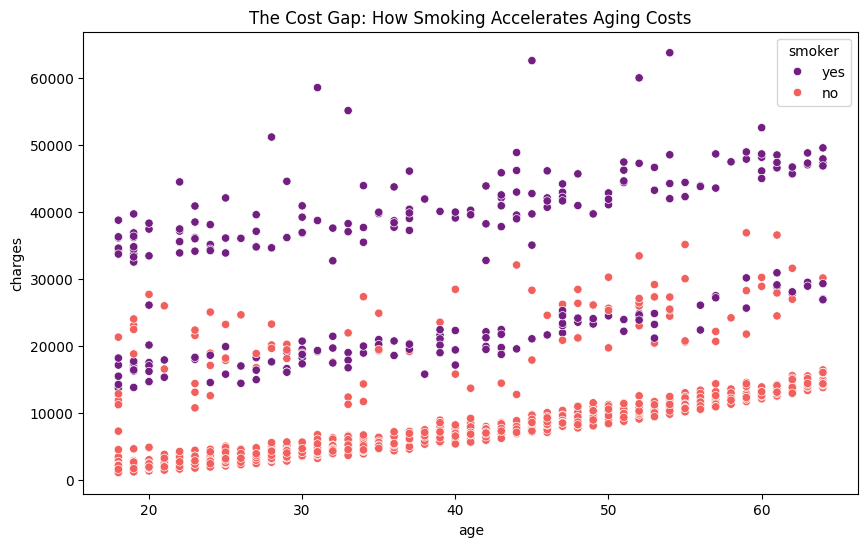

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='magma')
plt.title('The Cost Gap: How Smoking Accelerates Aging Costs')
plt.show()